# IMC Backtester Log Viewer

Granular per-tick visualization of submitted bot runs.  
Point `LOG_DIR` at any `logs/<id>/` directory and re-run cells.

**Sections:**  
1. Parser — turn `.log`/`.json` into structured DataFrames  
2. Aggregate views — PnL, positions, trades, counterparty matrix  
3. Per-tick view (`render_tick`) — orderbook + trades + position around a single timestamp  
4. Event filters — find interesting ticks (drawdowns, large fills, CP-specific)

In [1]:
import json
import io
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
plt.rcParams['figure.dpi'] = 100

POSITION_LIMITS = {
    'HYDROGEL_PACK': 200, 'VELVETFRUIT_EXTRACT': 200,
    'VEV_4000': 300, 'VEV_4500': 300, 'VEV_5000': 300, 'VEV_5100': 300,
    'VEV_5200': 300, 'VEV_5300': 300, 'VEV_5400': 300, 'VEV_5500': 300,
    'VEV_6000': 300, 'VEV_6500': 300,
}

## 1. Parser

In [2]:
def parse_log(path):
    """Parse an IMC backtest log directory or .log/.json file.
    Returns a dict containing:
      submission_id, log_path, products, counterparties, all_ts
      activities (full snapshot DF), book[product] (per-product DF), mid (wide DF)
      trades (DF with side B/S/M, signed_qty, signed_cash, cp)
      position (wide DF, ts × product), cash (wide DF)
      pnl_per_product (cash + pos*mid), pnl_total (Series, prefer graphLog)
    """
    p = Path(path)
    if p.is_dir():
        candidates = sorted(p.glob('*.log')) or sorted(p.glob('*.json'))
        if not candidates:
            raise FileNotFoundError(f"No .log or .json file in {p}")
        log_path = candidates[0]
    else:
        log_path = p

    raw = json.load(open(log_path))

    # Activities = orderbook snapshots
    act = pd.read_csv(io.StringIO(raw['activitiesLog']), sep=';')
    book_per_product = {prod: g.sort_values('timestamp').reset_index(drop=True)
                        for prod, g in act.groupby('product')}
    mid_wide = act.pivot_table(index='timestamp', columns='product',
                                values='mid_price', aggfunc='first').sort_index()

    # Trades — annotate side/cp/signed cash
    trades = pd.DataFrame(raw.get('tradeHistory', []))
    if not trades.empty:
        trades['side'] = np.where(trades['buyer'] == 'SUBMISSION', 'B',
                          np.where(trades['seller'] == 'SUBMISSION', 'S', 'M'))
        trades['signed_qty'] = np.where(trades['side'] == 'B',  trades['quantity'],
                                np.where(trades['side'] == 'S', -trades['quantity'], 0))
        trades['signed_cash'] = -trades['signed_qty'] * trades['price']
        trades['cp'] = np.where(trades['side'] == 'B', trades['seller'],
                       np.where(trades['side'] == 'S', trades['buyer'],
                                trades['buyer'].astype(str) + '↔' + trades['seller'].astype(str)))
    else:
        for col in ['side', 'signed_qty', 'signed_cash', 'cp']:
            trades[col] = pd.Series(dtype='object')

    # Position & cash carried forward, indexed at every snapshot ts
    all_ts = sorted(act['timestamp'].unique())
    sub = trades[trades['side'].isin(['B', 'S'])]
    if not sub.empty:
        pos = sub.pivot_table(index='timestamp', columns='symbol',
                              values='signed_qty', aggfunc='sum').fillna(0).cumsum()
        cash = sub.pivot_table(index='timestamp', columns='symbol',
                               values='signed_cash', aggfunc='sum').fillna(0).cumsum()
        pos = pos.reindex(all_ts).ffill().fillna(0)
        cash = cash.reindex(all_ts).ffill().fillna(0)
    else:
        pos = pd.DataFrame(index=all_ts)
        cash = pd.DataFrame(index=all_ts)

    # Per-product MTM PnL = cash + pos·mid
    common = mid_wide.columns.intersection(pos.columns) if len(pos.columns) else []
    pnl_per_product = (pos[common] * mid_wide.reindex(pos.index)[common] + cash[common]) if len(common) else pd.DataFrame(index=all_ts)

    # Total PnL: prefer graphLog from co-located .json
    pnl_total = None
    json_path = log_path.with_suffix('.json')
    if json_path.exists() and json_path != log_path:
        try:
            extra = json.load(open(json_path))
            if 'graphLog' in extra:
                gl = pd.read_csv(io.StringIO(extra['graphLog']), sep=';')
                pnl_total = pd.Series(gl['value'].values, index=gl['timestamp'])
        except Exception:
            pass
    if pnl_total is None and not pnl_per_product.empty:
        pnl_total = pnl_per_product.sum(axis=1)

    return {
        'submission_id': raw.get('submissionId', '?'),
        'log_path': str(log_path),
        'activities': act,
        'book': book_per_product,
        'mid': mid_wide,
        'trades': trades,
        'position': pos,
        'cash': cash,
        'pnl_per_product': pnl_per_product,
        'pnl_total': pnl_total,
        'counterparties': sorted(set(trades['cp'].dropna()) - {'SUBMISSION'}) if not trades.empty else [],
        'all_ts': all_ts,
        'products': sorted(book_per_product.keys()),
    }

## 2. Load a log

Change `LOG_DIR` to any `logs/<id>/` folder. Re-running this cell loads a different submission.

In [3]:
LOG_DIR = 'logs/525535'

parsed = parse_log(LOG_DIR)

print(f"Submission:    {parsed['submission_id']}")
print(f"Log file:      {parsed['log_path']}")
print(f"Products:      {len(parsed['products'])}  ({', '.join(parsed['products'])})")
print(f"Counterparties:{len(parsed['counterparties'])} {parsed['counterparties']}")
print(f"Trades:        {len(parsed['trades']):,}  "
      f"(SUB buys={(parsed['trades']['side']=='B').sum()}, "
      f"SUB sells={(parsed['trades']['side']=='S').sum()}, "
      f"market-only={(parsed['trades']['side']=='M').sum()})")
print(f"Timestamps:    {min(parsed['all_ts']):,} → {max(parsed['all_ts']):,}  ({len(parsed['all_ts'])} snapshots)")
if parsed['pnl_total'] is not None:
    print(f"Final PnL:     {parsed['pnl_total'].iloc[-1]:+,.2f}")
    print(f"Max drawdown:  {(parsed['pnl_total'] - parsed['pnl_total'].cummax()).min():+,.2f}")

Submission:    21fc6d0a-c48f-47af-9c2c-d1f5a54f98e2
Log file:      logs/525535/525535.log
Products:      12  (HYDROGEL_PACK, VELVETFRUIT_EXTRACT, VEV_4000, VEV_4500, VEV_5000, VEV_5100, VEV_5200, VEV_5300, VEV_5400, VEV_5500, VEV_6000, VEV_6500)
Counterparties:12 ['Mark 01', 'Mark 01↔Mark 22', 'Mark 14', 'Mark 14↔Mark 22', 'Mark 14↔Mark 38', 'Mark 22', 'Mark 38', 'Mark 49', 'Mark 55', 'Mark 55↔Mark 01', 'Mark 55↔Mark 14', 'Mark 67']
Trades:        322  (SUB buys=128, SUB sells=128, market-only=66)
Timestamps:    0 → 99,900  (1000 snapshots)
Final PnL:     +13,082.63
Max drawdown:  -5,003.67


## 3. PnL curve — total + per-product

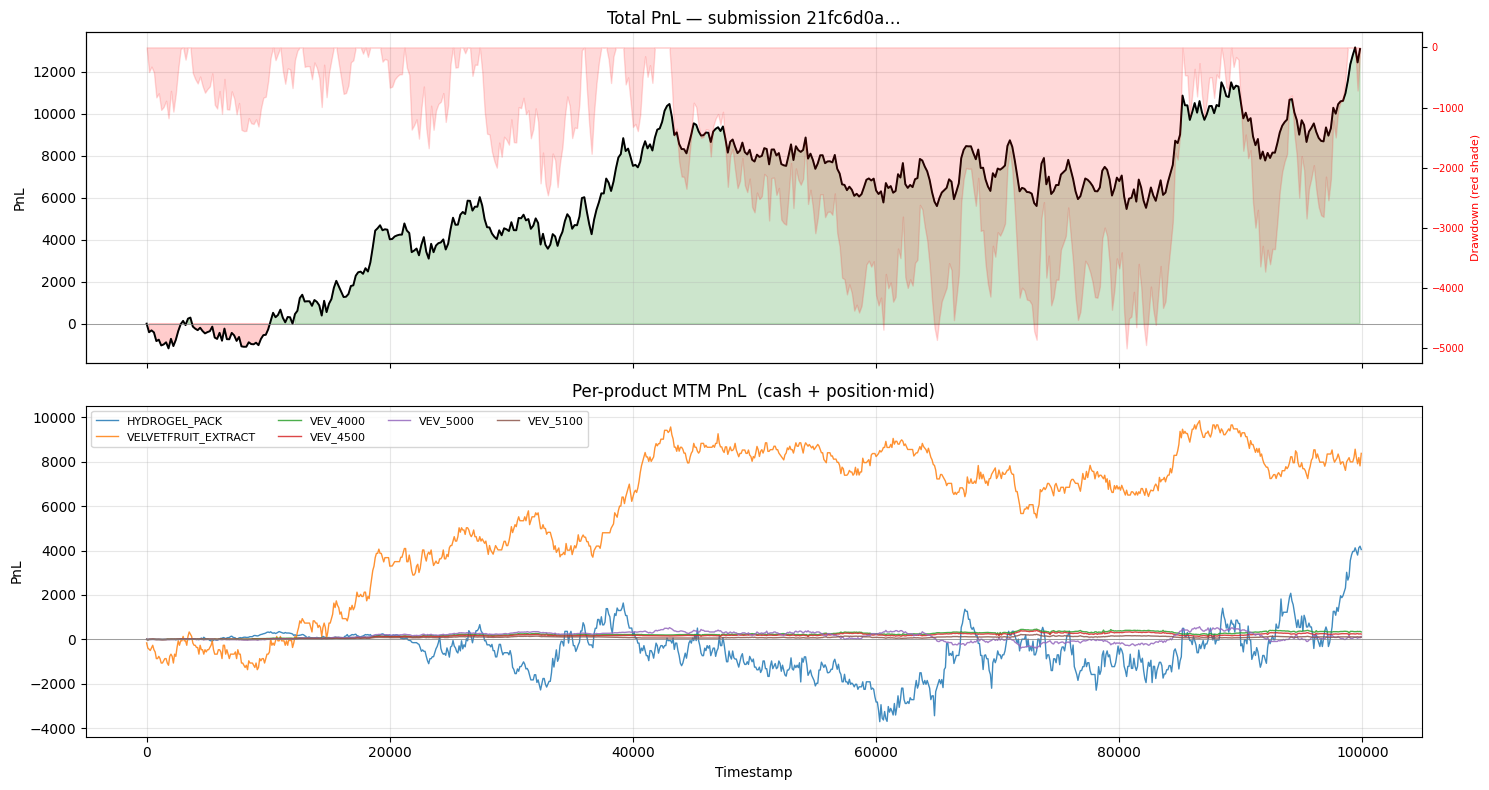


Final per-product PnL:
  VEV_5100                    +97.00
  VEV_5000                   +131.00
  VEV_4500                   +239.00
  VEV_4000                   +336.00
  HYDROGEL_PACK             +4047.00
  VELVETFRUIT_EXTRACT       +8380.00


In [4]:
def plot_pnl(parsed):
    fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

    ax = axes[0]
    if parsed['pnl_total'] is not None:
        pt = parsed['pnl_total']
        ax.plot(pt.index, pt.values, lw=1.4, color='black')
        ax.axhline(0, color='gray', lw=0.5)
        ax.fill_between(pt.index, 0, pt.values, where=pt.values >= 0, color='green', alpha=0.2)
        ax.fill_between(pt.index, 0, pt.values, where=pt.values < 0,  color='red',   alpha=0.2)
        # Drawdown shading
        peak = pt.cummax()
        dd = pt - peak
        ax2 = ax.twinx()
        ax2.fill_between(dd.index, 0, dd.values, color='red', alpha=0.15)
        ax2.set_ylabel('Drawdown (red shade)', color='red', fontsize=8)
        ax2.tick_params(axis='y', labelcolor='red', labelsize=7)
    ax.set_title(f"Total PnL — submission {parsed['submission_id'][:8]}…")
    ax.set_ylabel('PnL'); ax.grid(alpha=0.3)

    ax = axes[1]
    if not parsed['pnl_per_product'].empty:
        for col in parsed['pnl_per_product'].columns:
            ax.plot(parsed['pnl_per_product'].index, parsed['pnl_per_product'][col],
                    label=col, lw=1, alpha=0.85)
    ax.axhline(0, color='gray', lw=0.5)
    ax.set_title('Per-product MTM PnL  (cash + position·mid)')
    ax.set_xlabel('Timestamp'); ax.set_ylabel('PnL')
    ax.legend(ncol=4, fontsize=8); ax.grid(alpha=0.3)

    plt.tight_layout(); plt.show()

    if not parsed['pnl_per_product'].empty:
        finals = parsed['pnl_per_product'].iloc[-1].sort_values()
        print("\nFinal per-product PnL:")
        for prod, v in finals.items():
            print(f"  {prod:<22}  {v:+10.2f}")

plot_pnl(parsed)

## 4. Trade markers per product

Bid/ask track + colored markers for SUBMISSION fills (▲ buy, ▼ sell), tinted by counterparty.
Gray dots = market-only trades (no SUBMISSION involvement).

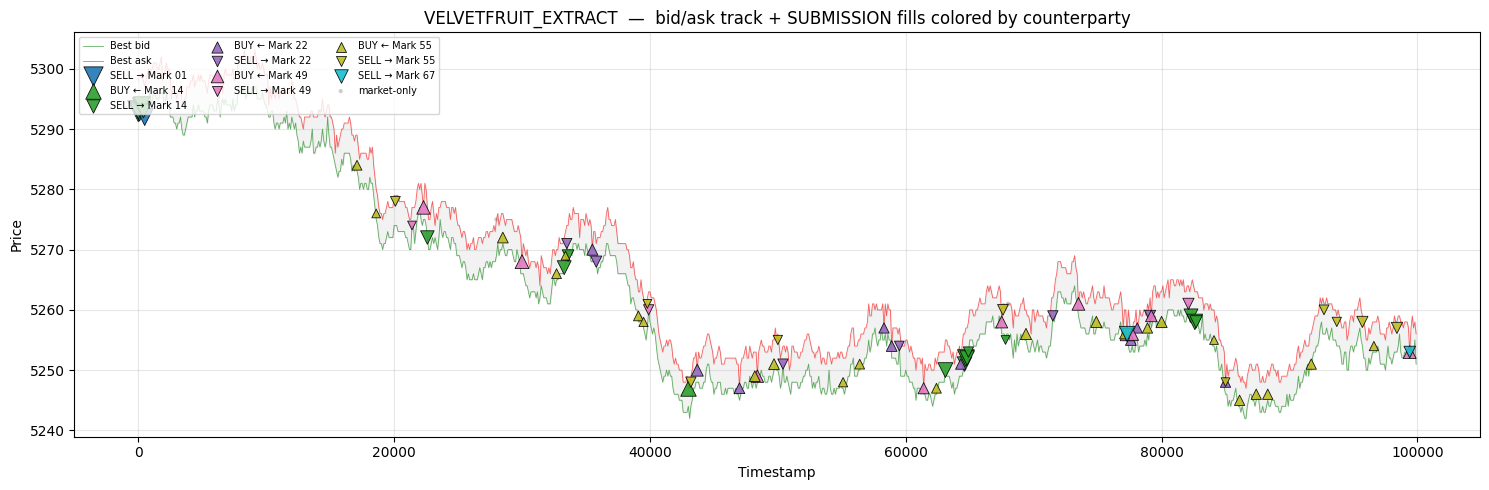

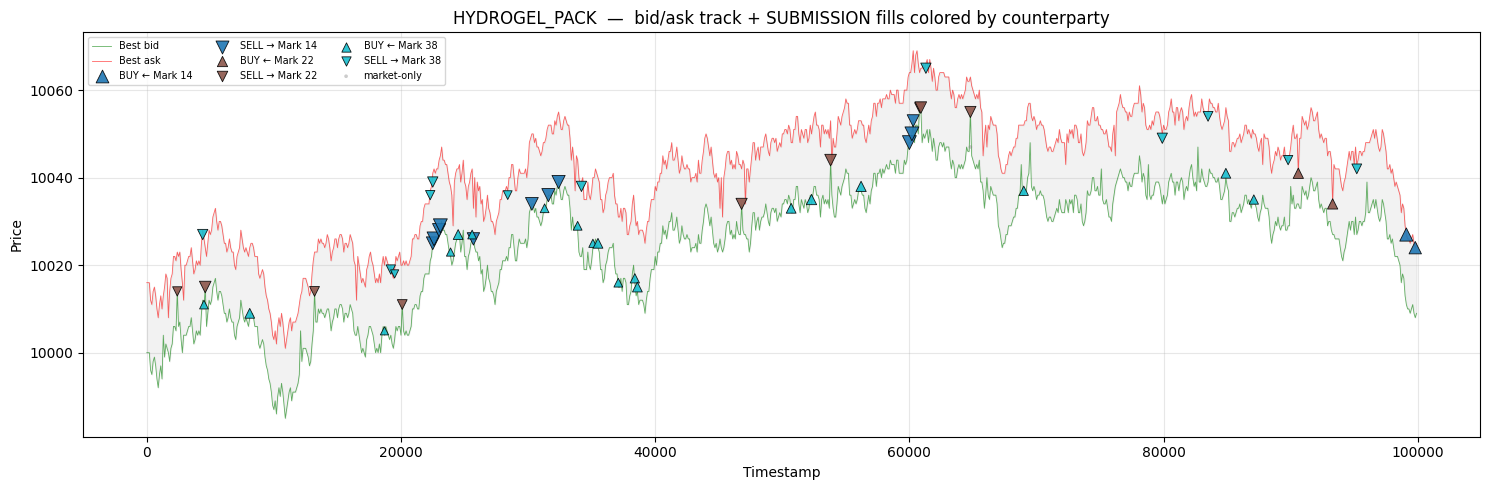

In [5]:
def plot_trade_markers(parsed, product, ts_window=None):
    book = parsed['book'].get(product)
    if book is None:
        print(f"No book data for {product}"); return
    sub_trades = parsed['trades'][(parsed['trades']['symbol'] == product) &
                                  (parsed['trades']['side'].isin(['B', 'S']))]
    mkt_trades = parsed['trades'][(parsed['trades']['symbol'] == product) &
                                  (parsed['trades']['side'] == 'M')]

    if ts_window:
        lo, hi = ts_window
        book = book[(book['timestamp'] >= lo) & (book['timestamp'] <= hi)]
        sub_trades = sub_trades[(sub_trades['timestamp'] >= lo) & (sub_trades['timestamp'] <= hi)]
        mkt_trades = mkt_trades[(mkt_trades['timestamp'] >= lo) & (mkt_trades['timestamp'] <= hi)]

    fig, ax = plt.subplots(figsize=(15, 5))
    ax.plot(book['timestamp'], book['bid_price_1'], color='green', lw=0.6, alpha=0.6, label='Best bid')
    ax.plot(book['timestamp'], book['ask_price_1'], color='red',   lw=0.6, alpha=0.6, label='Best ask')
    ax.fill_between(book['timestamp'], book['bid_price_1'], book['ask_price_1'], color='gray', alpha=0.1)

    cps = sorted(sub_trades['cp'].dropna().unique())
    cmap = cm.tab10(np.linspace(0, 1, max(len(cps), 1)))
    cp_color = {cp: cmap[i] for i, cp in enumerate(cps)}

    for cp in cps:
        bsel = sub_trades[(sub_trades['cp'] == cp) & (sub_trades['side'] == 'B')]
        ssel = sub_trades[(sub_trades['cp'] == cp) & (sub_trades['side'] == 'S')]
        if len(bsel):
            ax.scatter(bsel['timestamp'], bsel['price'], marker='^', s=bsel['quantity']*5+25,
                       color=cp_color[cp], edgecolors='black', linewidths=0.6,
                       label=f'BUY ← {cp}', zorder=5, alpha=0.9)
        if len(ssel):
            ax.scatter(ssel['timestamp'], ssel['price'], marker='v', s=ssel['quantity']*5+25,
                       color=cp_color[cp], edgecolors='black', linewidths=0.6,
                       label=f'SELL → {cp}', zorder=5, alpha=0.9)

    if len(mkt_trades):
        ax.scatter(mkt_trades['timestamp'], mkt_trades['price'], marker='o', s=mkt_trades['quantity']+5,
                   color='gray', alpha=0.4, edgecolors='none', zorder=3, label='market-only')

    ax.set_title(f"{product}  —  bid/ask track + SUBMISSION fills colored by counterparty")
    ax.set_xlabel('Timestamp'); ax.set_ylabel('Price')
    ax.legend(ncol=3, fontsize=7, loc='upper left')
    ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

for p in ['VELVETFRUIT_EXTRACT', 'HYDROGEL_PACK']:
    if p in parsed['products']:
        plot_trade_markers(parsed, p)

## 5. Position timeline (small multiples)

Per product: position vs limit caps (dashed) on left axis, mid in gray on right axis.

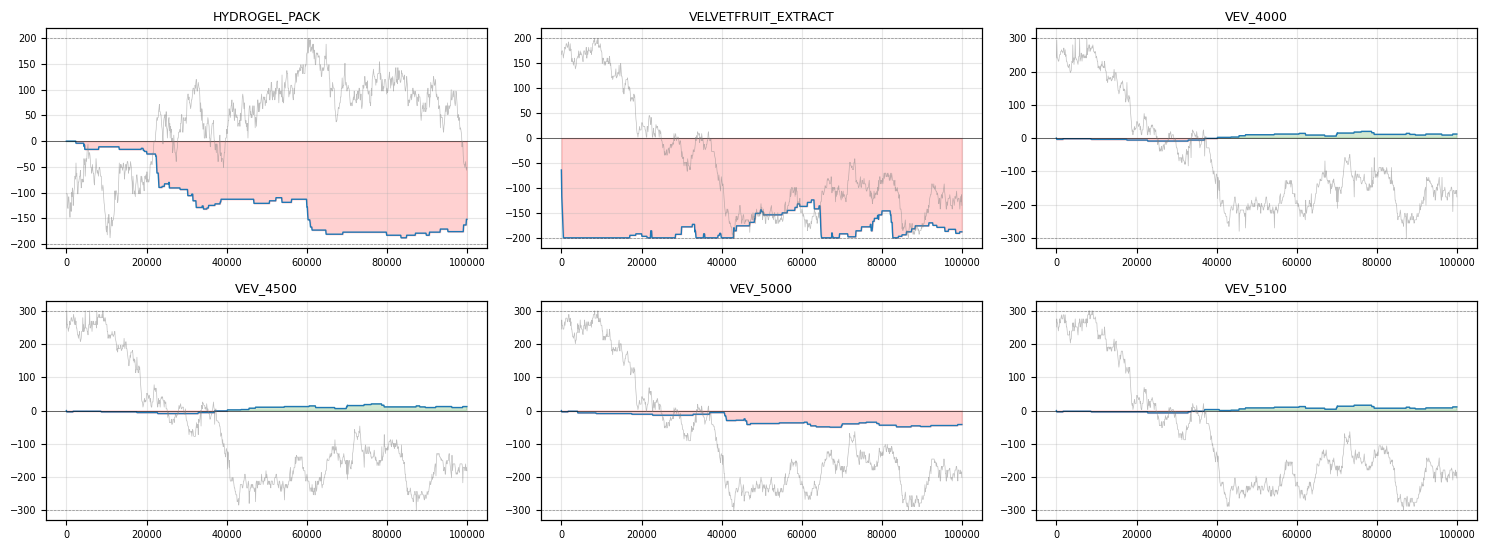

In [6]:
def plot_position_timeline(parsed):
    products = [p for p in parsed['products'] if p in parsed['position'].columns]
    n = len(products)
    if n == 0:
        print("No position data"); return
    cols = 3; rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 2.8 * rows))
    axes = np.array(axes).flatten()
    for i, prod in enumerate(products):
        ax = axes[i]
        pos = parsed['position'][prod]
        ax.plot(pos.index, pos.values, color='C0', lw=1)
        ax.fill_between(pos.index, 0, pos.values, where=pos.values >= 0, color='green', alpha=0.18)
        ax.fill_between(pos.index, 0, pos.values, where=pos.values <  0, color='red',   alpha=0.18)
        ax.axhline(0, color='black', lw=0.4)
        lim = POSITION_LIMITS.get(prod)
        if lim:
            ax.axhline(+lim, color='black', ls='--', lw=0.5, alpha=0.4)
            ax.axhline(-lim, color='black', ls='--', lw=0.5, alpha=0.4)
        ax2 = ax.twinx()
        if prod in parsed['mid'].columns:
            ax2.plot(parsed['mid'].index, parsed['mid'][prod], color='gray', lw=0.5, alpha=0.5)
        ax2.set_yticks([])
        ax.set_title(prod, fontsize=9)
        ax.tick_params(axis='both', labelsize=7)
        ax.grid(alpha=0.3)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout(); plt.show()

plot_position_timeline(parsed)

## 6. Counterparty fill matrix

**Left:** Net SUBMISSION position change per (CP, product). Positive = SUB net bought from this CP.  
**Right:** Trade count per cell (sample-size context for the toxicity heatmap below).

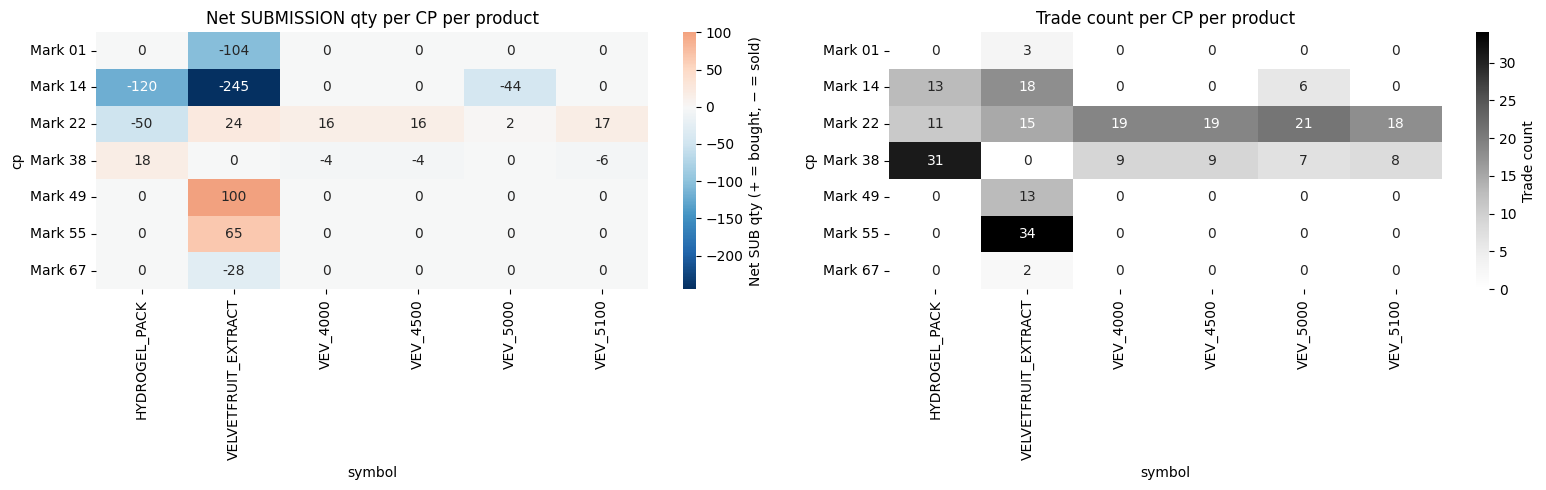

In [7]:
def plot_cp_matrix(parsed):
    sub = parsed['trades'][parsed['trades']['side'].isin(['B', 'S'])].copy()
    if sub.empty:
        print("No SUBMISSION trades"); return

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    pivot_qty = sub.pivot_table(index='cp', columns='symbol', values='signed_qty',
                                 aggfunc='sum', fill_value=0)
    sns.heatmap(pivot_qty, annot=True, fmt='.0f', cmap='RdBu_r', center=0, ax=axes[0],
                cbar_kws={'label': 'Net SUB qty (+ = bought, − = sold)'})
    axes[0].set_title('Net SUBMISSION qty per CP per product')

    pivot_n = sub.pivot_table(index='cp', columns='symbol', values='quantity',
                               aggfunc='count', fill_value=0)
    sns.heatmap(pivot_n, annot=True, fmt='.0f', cmap='Greys', ax=axes[1],
                cbar_kws={'label': 'Trade count'})
    axes[1].set_title('Trade count per CP per product')
    plt.tight_layout(); plt.show()

plot_cp_matrix(parsed)

## 7. Counterparty toxicity (forward PnL on SUB fills)

For each SUB fill at price `p`, compute `(mid_at_h − p) × signed_qty` — i.e., the per-trade  
MTM PnL we'd realize if we simply held the fill for `horizon_ts` ticks.

Negative cells = CPs whose flow we lost on. Positive = CPs we extracted edge from.

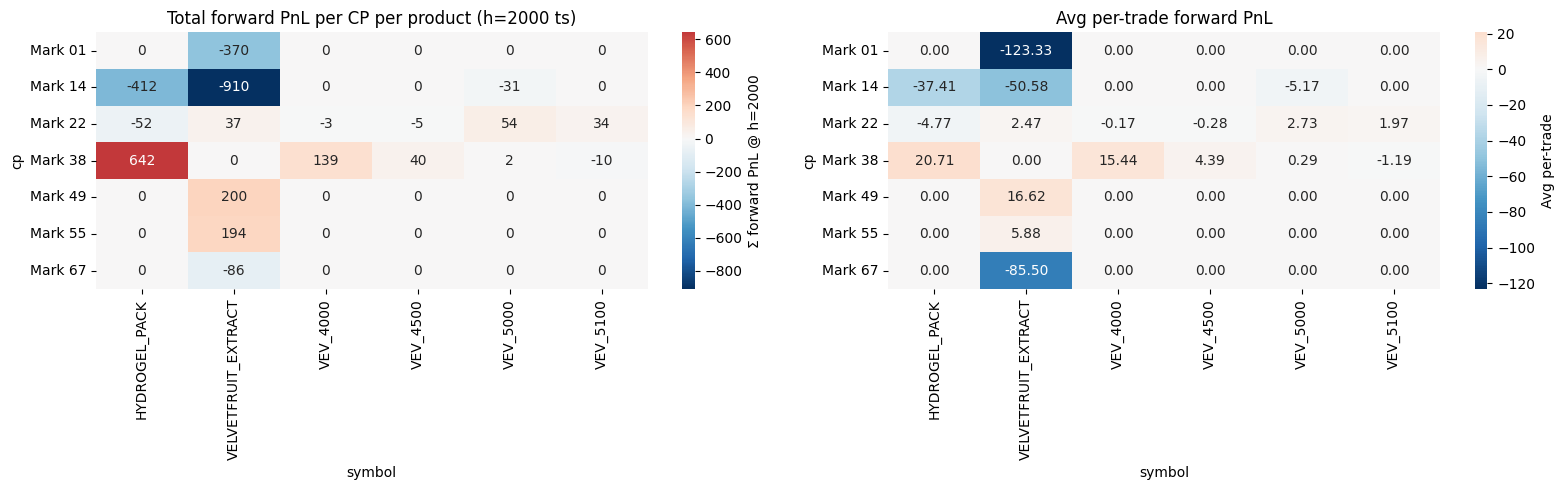

In [8]:
def plot_cp_toxicity(parsed, horizon_ts=2000):
    sub = parsed['trades'][parsed['trades']['side'].isin(['B', 'S'])].copy()
    if sub.empty:
        print("No SUBMISSION trades"); return

    rows = []
    for _, tr in sub.iterrows():
        prod = tr['symbol']
        if prod not in parsed['mid'].columns: continue
        mid_s = parsed['mid'][prod].dropna()
        idx_h = mid_s.index.searchsorted(tr['timestamp'] + horizon_ts)
        if idx_h >= len(mid_s): continue
        mh = mid_s.iloc[idx_h]
        signed = tr['quantity'] if tr['side'] == 'B' else -tr['quantity']
        rows.append({'cp': tr['cp'], 'symbol': prod,
                     'pnl_sum': (mh - tr['price']) * signed,
                     'pnl_avg': (mh - tr['price']) * signed})
    df = pd.DataFrame(rows)
    if df.empty:
        print("No fills with sufficient horizon"); return

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    sum_p = df.groupby(['cp', 'symbol'])['pnl_sum'].sum().unstack(fill_value=0)
    sns.heatmap(sum_p, annot=True, fmt='.0f', cmap='RdBu_r', center=0, ax=axes[0],
                cbar_kws={'label': f'Σ forward PnL @ h={horizon_ts}'})
    axes[0].set_title(f'Total forward PnL per CP per product (h={horizon_ts} ts)')

    avg_p = df.groupby(['cp', 'symbol'])['pnl_avg'].mean().unstack(fill_value=0)
    sns.heatmap(avg_p, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=axes[1],
                cbar_kws={'label': 'Avg per-trade'})
    axes[1].set_title('Avg per-trade forward PnL')
    plt.tight_layout(); plt.show()

plot_cp_toxicity(parsed, horizon_ts=2000)

## 8. Inventory utilization

How close to position limits did we run? `pct_at_cap` = % of time at ≥90% of limit.

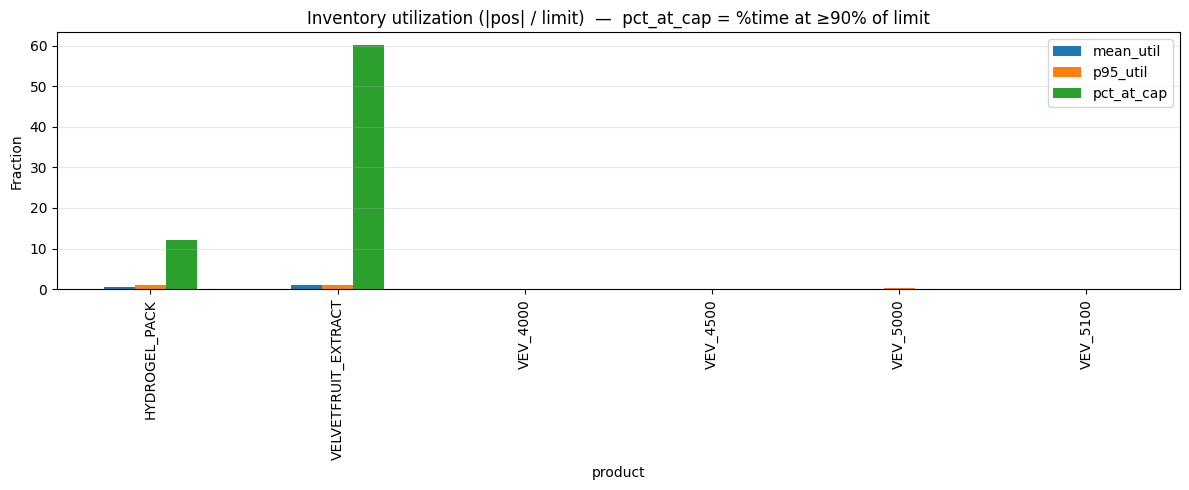

                     mean_util  p95_util  pct_at_cap
product                                             
HYDROGEL_PACK            0.577     0.915        12.2
VELVETFRUIT_EXTRACT      0.910     1.000        60.3
VEV_4000                 0.028     0.053         0.0
VEV_4500                 0.028     0.053         0.0
VEV_5000                 0.095     0.163         0.0
VEV_5100                 0.022     0.043         0.0


In [9]:
def plot_inventory_risk(parsed):
    products = [p for p in parsed['position'].columns if POSITION_LIMITS.get(p)]
    if not products:
        print("No position data"); return
    rows = []
    for prod in products:
        pos = parsed['position'][prod].dropna()
        lim = POSITION_LIMITS[prod]
        ratio = pos.abs() / lim
        rows.append({'product': prod, 'mean_util': ratio.mean(),
                     'p95_util': ratio.quantile(0.95),
                     'pct_at_cap': float((ratio >= 0.9).mean() * 100)})
    df = pd.DataFrame(rows).set_index('product')
    fig, ax = plt.subplots(figsize=(12, 5))
    df.plot(kind='bar', ax=ax)
    ax.set_title('Inventory utilization (|pos| / limit)  —  pct_at_cap = %time at ≥90% of limit')
    ax.set_ylabel('Fraction'); ax.grid(alpha=0.3, axis='y')
    plt.tight_layout(); plt.show()
    print(df.round(3))

plot_inventory_risk(parsed)

## 9. Per-tick view — `render_tick(parsed, ts, product)`

Five-panel snapshot of one iteration:

1. **Top-left:** L1/L2/L3 orderbook bars (green=bid, red=ask, yellow band=spread)  
2. **Top-right:** mid ± window with bid/ask shading and trade markers (red vline = current ts)  
3. **Mid-left:** trades AT this ts (text table; ★ = SUBMISSION involved)  
4. **Mid-right:** position around this ts (limit caps dashed)  
5. **Bottom:** total PnL around this ts

In [10]:
def render_tick(parsed, ts, product, window=2000):
    book = parsed['book'].get(product)
    if book is None:
        print(f"Unknown product {product}"); return
    snap = book[book['timestamp'] == ts]
    if snap.empty:
        print(f"No snapshot at ts={ts} for {product}"); return
    snap = snap.iloc[0]

    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(3, 2, height_ratios=[2.4, 2.0, 1.4], hspace=0.45, wspace=0.25)

    # ─── Top-left: orderbook L1/L2/L3 ──────────────────────────────
    ax = fig.add_subplot(gs[0, 0])
    for lvl in [1, 2, 3]:
        ap = snap.get(f'ask_price_{lvl}'); av = snap.get(f'ask_volume_{lvl}')
        if pd.notna(ap):
            ax.barh(ap, av, color='red', alpha=0.55 + 0.15 * (3 - lvl) / 2, height=0.6)
            ax.text(av, ap, f"  L{lvl} {int(av)}", va='center', fontsize=8)
    spread = snap['ask_price_1'] - snap['bid_price_1']
    ax.axhspan(snap['bid_price_1'], snap['ask_price_1'], color='yellow', alpha=0.15)
    ax.text(0, (snap['bid_price_1'] + snap['ask_price_1']) / 2,
            f" spread={int(spread)}  mid={snap['mid_price']:.1f}", va='center', fontsize=8, fontweight='bold')
    for lvl in [1, 2, 3]:
        bp = snap.get(f'bid_price_{lvl}'); bv = snap.get(f'bid_volume_{lvl}')
        if pd.notna(bp):
            ax.barh(bp, bv, color='green', alpha=0.55 + 0.15 * (3 - lvl) / 2, height=0.6)
            ax.text(bv, bp, f"  L{lvl} {int(bv)}", va='center', fontsize=8)
    ax.set_title(f"{product}  orderbook @ ts={ts}")
    ax.set_xlabel('Volume'); ax.set_ylabel('Price'); ax.grid(alpha=0.3, axis='x')

    # ─── Top-right: mid window with trades ──────────────────────────
    ax = fig.add_subplot(gs[0, 1])
    sub_book = book[(book['timestamp'] >= ts - window) & (book['timestamp'] <= ts + window)]
    ax.plot(sub_book['timestamp'], sub_book['mid_price'], color='black', lw=1)
    ax.fill_between(sub_book['timestamp'], sub_book['bid_price_1'], sub_book['ask_price_1'],
                    color='gray', alpha=0.2)
    ax.axvline(ts, color='red', lw=1.5, alpha=0.7)
    tr_w = parsed['trades'][(parsed['trades']['symbol'] == product) &
                            (parsed['trades']['timestamp'] >= ts - window) &
                            (parsed['trades']['timestamp'] <= ts + window)]
    for _, tr in tr_w.iterrows():
        if tr['side'] == 'B':
            ax.scatter(tr['timestamp'], tr['price'], marker='^', color='green',
                       s=tr['quantity']*5+25, edgecolors='black', linewidths=0.5, zorder=5)
        elif tr['side'] == 'S':
            ax.scatter(tr['timestamp'], tr['price'], marker='v', color='red',
                       s=tr['quantity']*5+25, edgecolors='black', linewidths=0.5, zorder=5)
        else:
            ax.scatter(tr['timestamp'], tr['price'], marker='o', color='gray',
                       s=tr['quantity']+5, alpha=0.4, zorder=3)
    ax.set_title(f"{product} mid ± {window} ts")
    ax.set_xlabel('Timestamp'); ax.set_ylabel('Price'); ax.grid(alpha=0.3)

    # ─── Mid-left: trades AT this exact ts ──────────────────────────
    ax = fig.add_subplot(gs[1, 0]); ax.axis('off')
    at_ts = parsed['trades'][parsed['trades']['timestamp'] == ts]
    lines = [f"TRADES @ ts={ts}", "─" * 60]
    if at_ts.empty:
        lines.append("(no trades this tick)")
    else:
        # Same-product first, then others
        same = at_ts[at_ts['symbol'] == product]
        other = at_ts[at_ts['symbol'] != product]
        for _, tr in pd.concat([same, other]).iterrows():
            tag = '★ SUB BUY ' if tr['side']=='B' else ('★ SUB SELL' if tr['side']=='S' else '  market   ')
            lines.append(f"{tag}  {tr['symbol']:<22}  qty={int(tr['quantity']):>3}  @{tr['price']:>8.1f}   {tr['cp']}")
    ax.text(0.0, 1.0, '\n'.join(lines), fontfamily='monospace', fontsize=9,
            verticalalignment='top', transform=ax.transAxes)

    # ─── Mid-right: position around ts ──────────────────────────────
    ax = fig.add_subplot(gs[1, 1])
    if product in parsed['position'].columns:
        pos = parsed['position'][product]
        psub = pos[(pos.index >= ts - window) & (pos.index <= ts + window)]
        ax.plot(psub.index, psub.values, color='C0', lw=1.2)
        ax.fill_between(psub.index, 0, psub.values, where=psub.values >= 0, color='green', alpha=0.2)
        ax.fill_between(psub.index, 0, psub.values, where=psub.values <  0, color='red',   alpha=0.2)
        lim = POSITION_LIMITS.get(product)
        if lim:
            ax.axhline(+lim, color='black', ls='--', lw=0.5, alpha=0.4)
            ax.axhline(-lim, color='black', ls='--', lw=0.5, alpha=0.4)
        ax.axhline(0, color='black', lw=0.4)
        ax.axvline(ts, color='red', lw=1.5, alpha=0.7)
        before = pos.loc[pos.index <= ts]
        cur = before.iloc[-1] if len(before) else 0
        ax.set_title(f"Position around ts={ts}   (current = {cur:+.0f})")
        ax.set_xlabel('Timestamp'); ax.set_ylabel('Position'); ax.grid(alpha=0.3)
    else:
        ax.text(0.5, 0.5, '(no position data)', ha='center', va='center', transform=ax.transAxes)
        ax.axis('off')

    # ─── Bottom: total PnL around ts ────────────────────────────────
    ax = fig.add_subplot(gs[2, :])
    if parsed['pnl_total'] is not None:
        pt = parsed['pnl_total']
        ptw = pt[(pt.index >= ts - window) & (pt.index <= ts + window)]
        ax.plot(ptw.index, ptw.values, color='black', lw=1)
        ax.axhline(0, color='gray', lw=0.5)
        ax.fill_between(ptw.index, 0, ptw.values, where=ptw.values >= 0, color='green', alpha=0.2)
        ax.fill_between(ptw.index, 0, ptw.values, where=ptw.values <  0, color='red',   alpha=0.2)
        ax.axvline(ts, color='red', lw=1.5, alpha=0.7)
        before = pt.loc[pt.index <= ts]
        if len(before):
            ax.set_title(f"Total PnL around ts={ts}   (current = {before.iloc[-1]:+,.1f})")
        ax.set_xlabel('Timestamp'); ax.set_ylabel('PnL'); ax.grid(alpha=0.3)
    else:
        ax.set_title('(no total PnL series)')
        ax.axis('off')

    plt.suptitle(f"Tick view  —  submission {parsed['submission_id'][:8]}…  —  {product} @ ts={ts}",
                 fontsize=11, y=0.995)
    plt.show()

### Try it — first SUBMISSION trade in the log

First SUBMISSION trade: ts=0  VELVETFRUIT_EXTRACT  S 42 @ 5293.0  cp=Mark 01


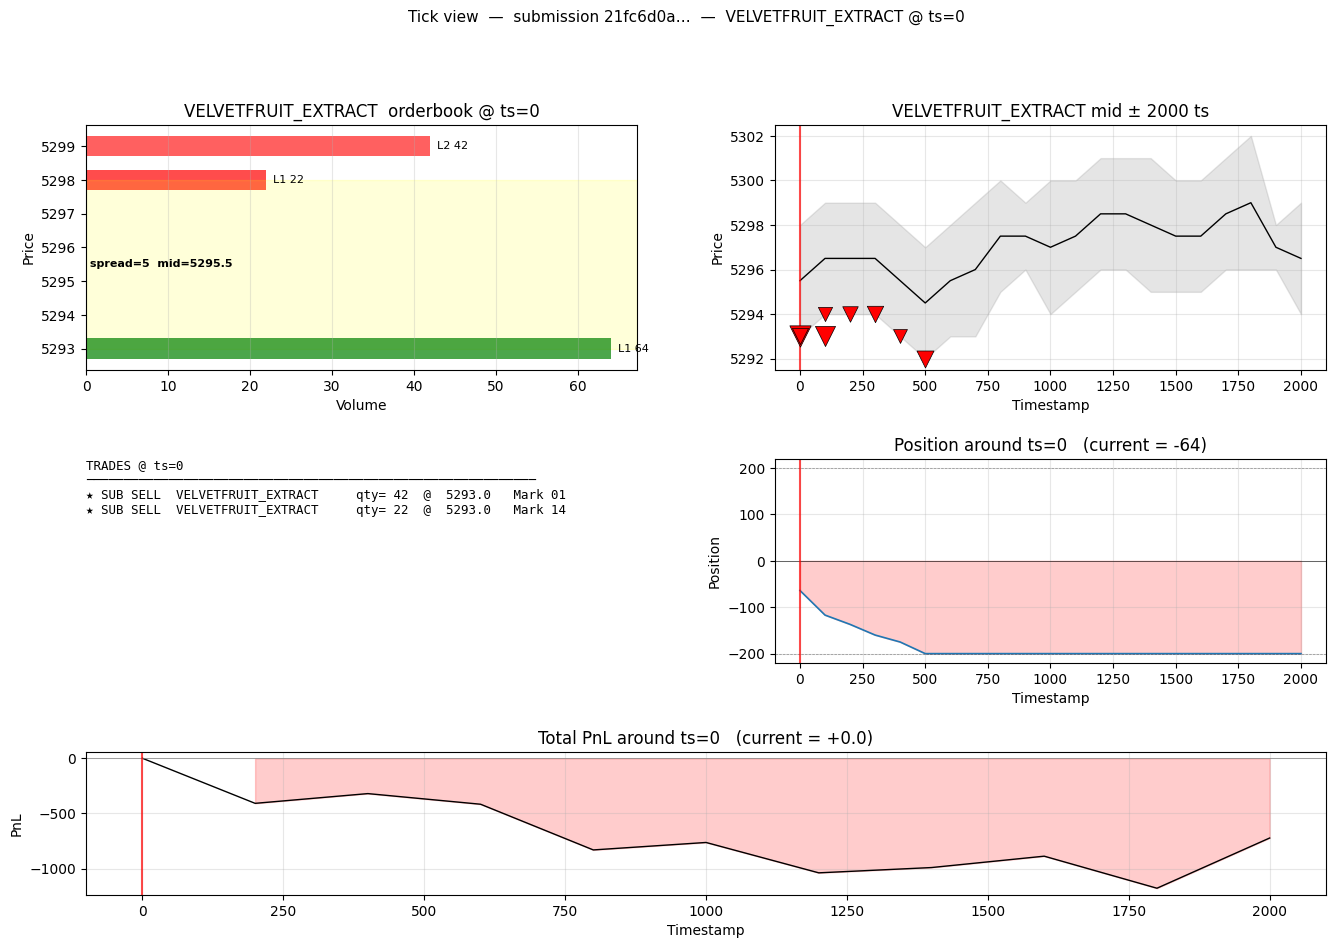

In [11]:
first_sub = parsed['trades'][parsed['trades']['side'].isin(['B', 'S'])].iloc[0]
print(f"First SUBMISSION trade: ts={first_sub['timestamp']}  {first_sub['symbol']}  "
      f"{first_sub['side']} {int(first_sub['quantity'])} @ {first_sub['price']}  cp={first_sub['cp']}")
render_tick(parsed, int(first_sub['timestamp']), first_sub['symbol'])

## 10. Event filters — find interesting ticks

Use these to skip to events of interest, then call `render_tick` on the result.

In [12]:
def find_events(parsed, kind, **kwargs):
    """Return a list of timestamps matching the predicate.

    kind options:
      'sub_trades'    — all ticks where SUB traded (optional product=)
      'cp_trades'     — all ticks where SUB traded with cp= (optional product=)
      'pnl_drawdown'  — top-n biggest drops vs trailing high (n=, window=)
      'position_max'  — top-n |pos| extremes for product= (n=)
      'large_fill'    — SUB fills with qty>=thr= (optional product=)
      'crossed_quote' — ticks where best_bid >= best_ask (product=)
    """
    t = parsed['trades']
    if kind == 'sub_trades':
        s = t[t['side'].isin(['B', 'S'])]
        if kwargs.get('product'): s = s[s['symbol'] == kwargs['product']]
        return sorted(s['timestamp'].unique().tolist())
    if kind == 'cp_trades':
        s = t[(t['side'].isin(['B', 'S'])) & (t['cp'] == kwargs['cp'])]
        if kwargs.get('product'): s = s[s['symbol'] == kwargs['product']]
        return sorted(s['timestamp'].unique().tolist())
    if kind == 'pnl_drawdown':
        if parsed['pnl_total'] is None: return []
        n = kwargs.get('n', 5); window = kwargs.get('window', 2000)
        pt = parsed['pnl_total']
        diff = pt - pt.rolling(window=window, min_periods=1).max()
        return list(diff.nsmallest(n).index)
    if kind == 'position_max':
        prod = kwargs['product']
        if prod not in parsed['position'].columns: return []
        pos = parsed['position'][prod]
        return list(pos.abs().nlargest(kwargs.get('n', 5)).index)
    if kind == 'large_fill':
        s = t[(t['side'].isin(['B', 'S'])) & (t['quantity'] >= kwargs.get('thr', 5))]
        if kwargs.get('product'): s = s[s['symbol'] == kwargs['product']]
        return sorted(s['timestamp'].unique().tolist())
    if kind == 'crossed_quote':
        b = parsed['book'].get(kwargs['product'])
        if b is None: return []
        crossed = b[b['bid_price_1'] >= b['ask_price_1']]
        return list(crossed['timestamp'])
    raise ValueError(f"Unknown kind: {kind}")

# Examples — adjust as needed
if 'Mark 67' in parsed['counterparties']:
    print("Mark 67 fills on VE:", find_events(parsed, 'cp_trades', cp='Mark 67', product='VELVETFRUIT_EXTRACT')[:10])
print("Top 5 PnL drawdown moments:", find_events(parsed, 'pnl_drawdown', n=5, window=2000))
print("Largest HP fills (qty>=10):", find_events(parsed, 'large_fill', product='HYDROGEL_PACK', thr=10)[:10])
print("Position extremes (VE):    ", find_events(parsed, 'position_max', product='VELVETFRUIT_EXTRACT', n=5))

Mark 67 fills on VE: [77300, 99400]
Top 5 PnL drawdown moments: [80600, 82200, 65000, 73200, 73000]
Largest HP fills (qty>=10): [22500, 22600, 23000, 23100, 25700, 30300, 31600, 32400, 60000, 60200]
Position extremes (VE):     [500, 600, 700, 800, 900]


## 11. Inspect a specific tick

Set `TS` and `PRODUCT`, then re-run.  
Tip: feed `find_events(...)` results in here to walk through a sequence of interesting ticks.

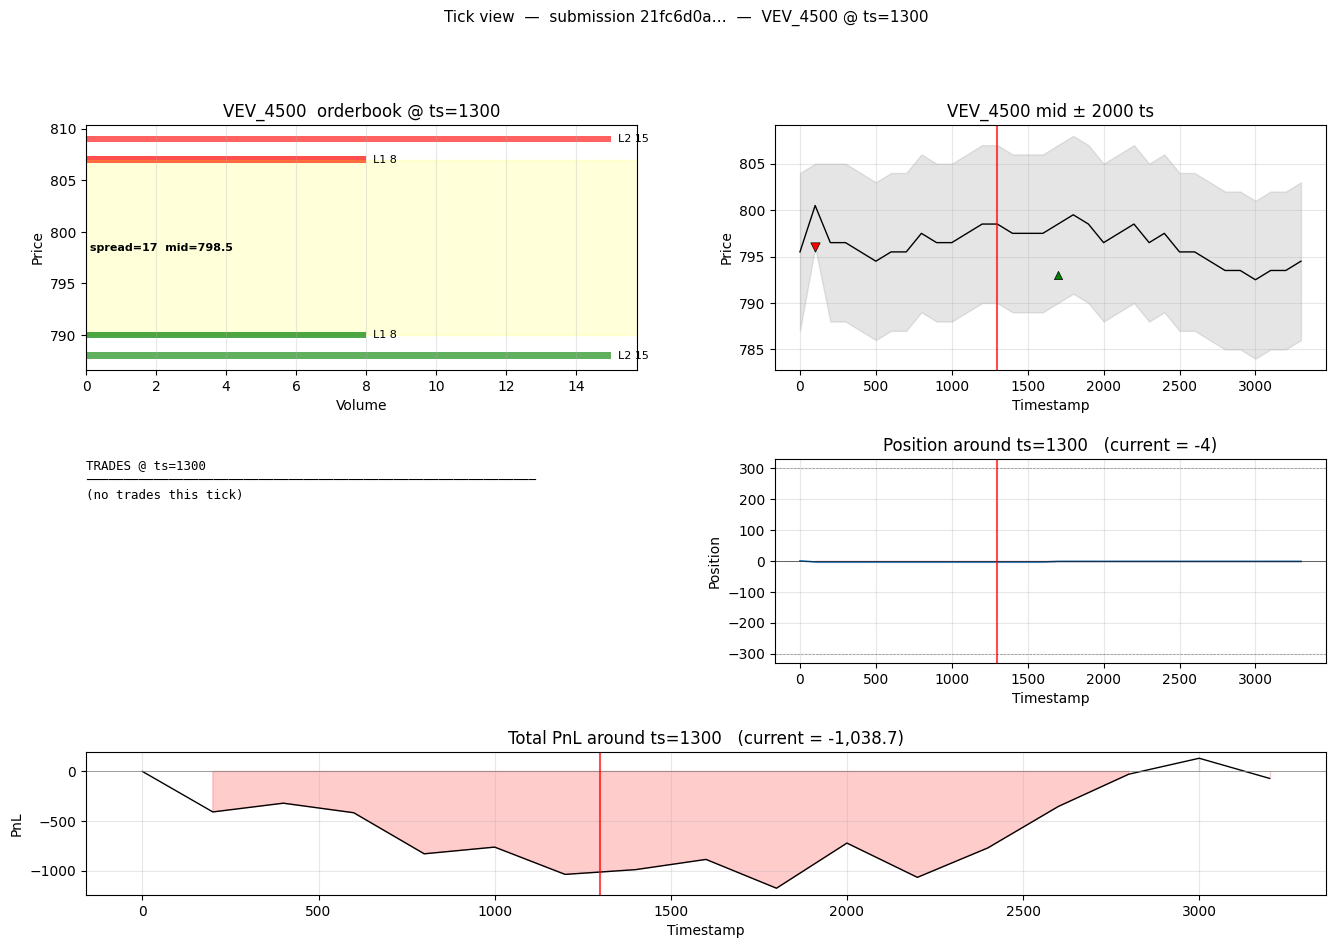

In [13]:
TS = 1300
PRODUCT = 'VEV_4500'
render_tick(parsed, TS, PRODUCT, window=2000)

## 12. Walk a sequence of ticks

Auto-render the first `K` ticks matching a filter. Useful for quickly auditing all moments where (e.g.) M67 traded with us.

2 matching ticks; rendering first 2


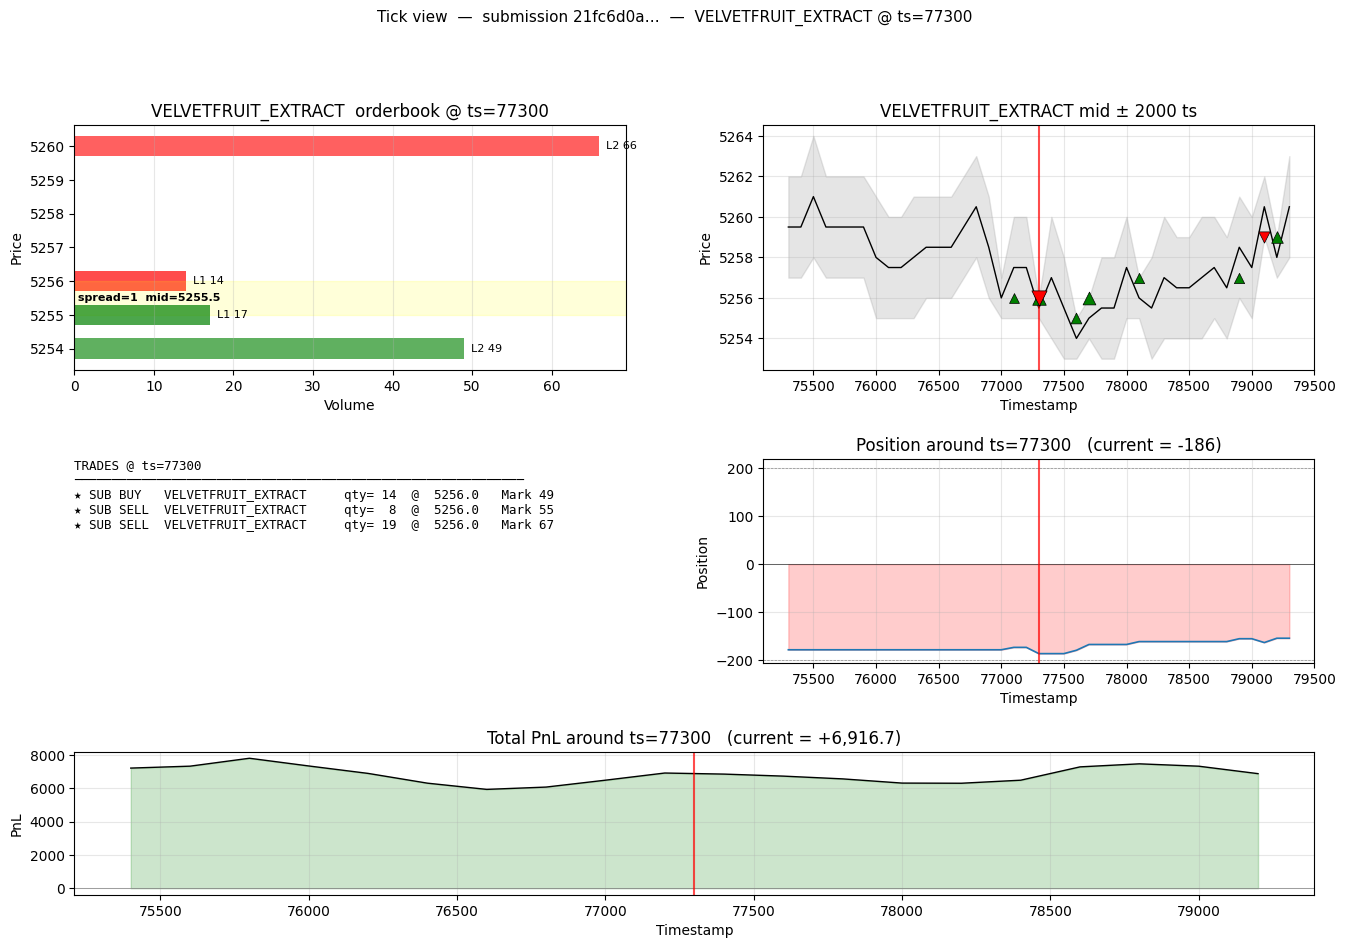

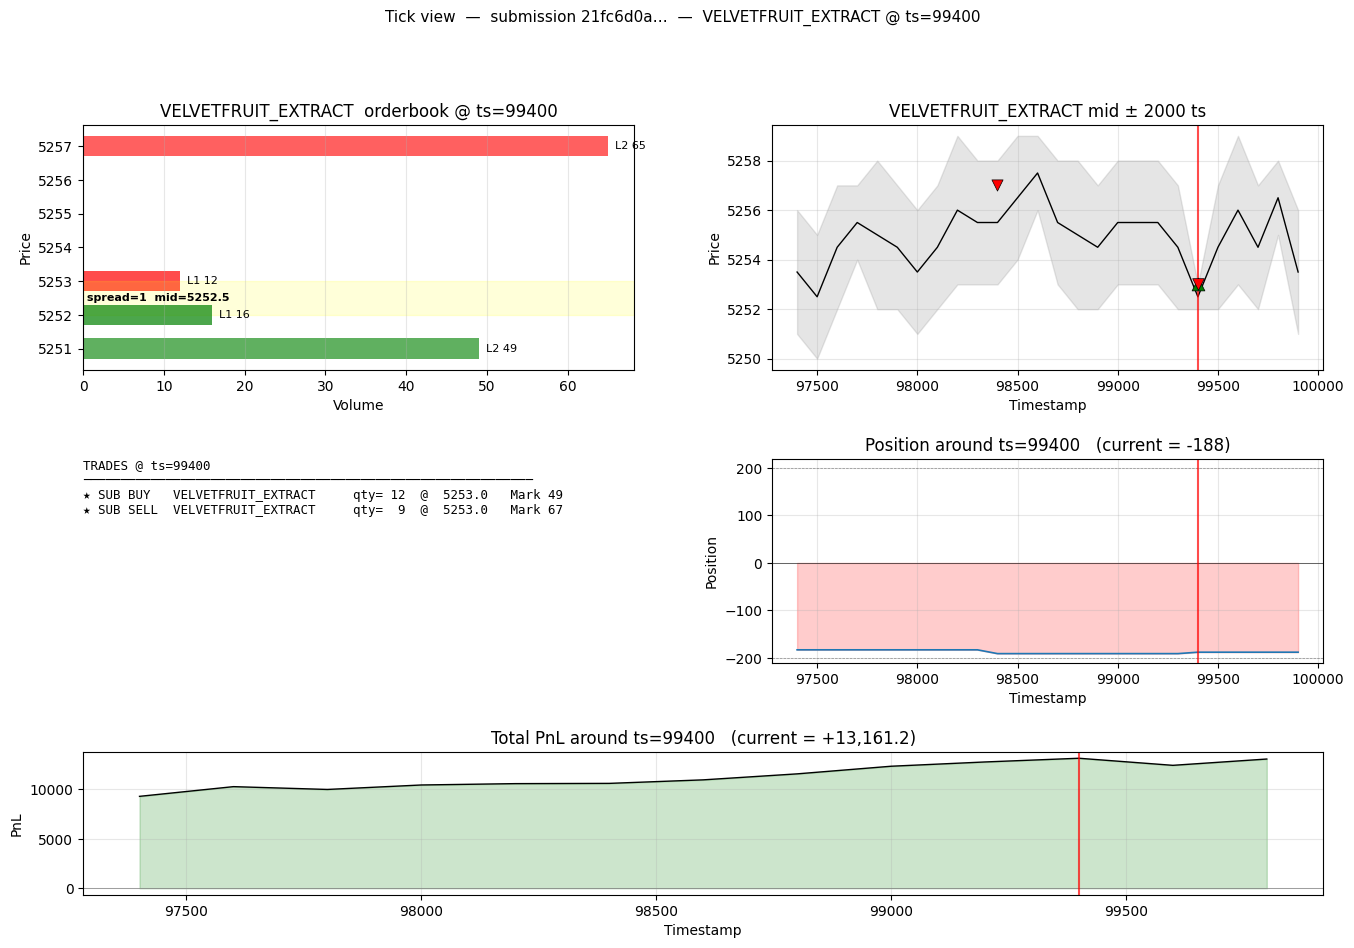

In [14]:
# Adjust the filter / product / count as you like.
PRODUCT_TO_WALK = 'VELVETFRUIT_EXTRACT'
FILTER_KIND = 'cp_trades'
FILTER_KW = dict(cp='Mark 67', product=PRODUCT_TO_WALK)
K = 3   # how many to render — keep small; each render is heavy

events = find_events(parsed, FILTER_KIND, **FILTER_KW)
print(f"{len(events)} matching ticks; rendering first {min(K, len(events))}")
for ts in events[:K]:
    render_tick(parsed, ts, PRODUCT_TO_WALK, window=2000)

## 13. Bot-to-bot trade flow

Trades where SUBMISSION was *not* involved (`side == 'M'` in the parsed trades).
In Round 4 these carry full `buyer`/`seller` Mark IDs, so we can see who-trades-with-whom without us in the picture.

**Two views below:**
1. Pairing matrix — total qty and count for every (buyer, seller) pair across all products.
2. Per-product timeline — markers on the bid/ask track at every bot-to-bot trade, colored by the seller and sized by qty.

Total bot-to-bot trades: 66
Distinct (buyer, seller) pairs: 5


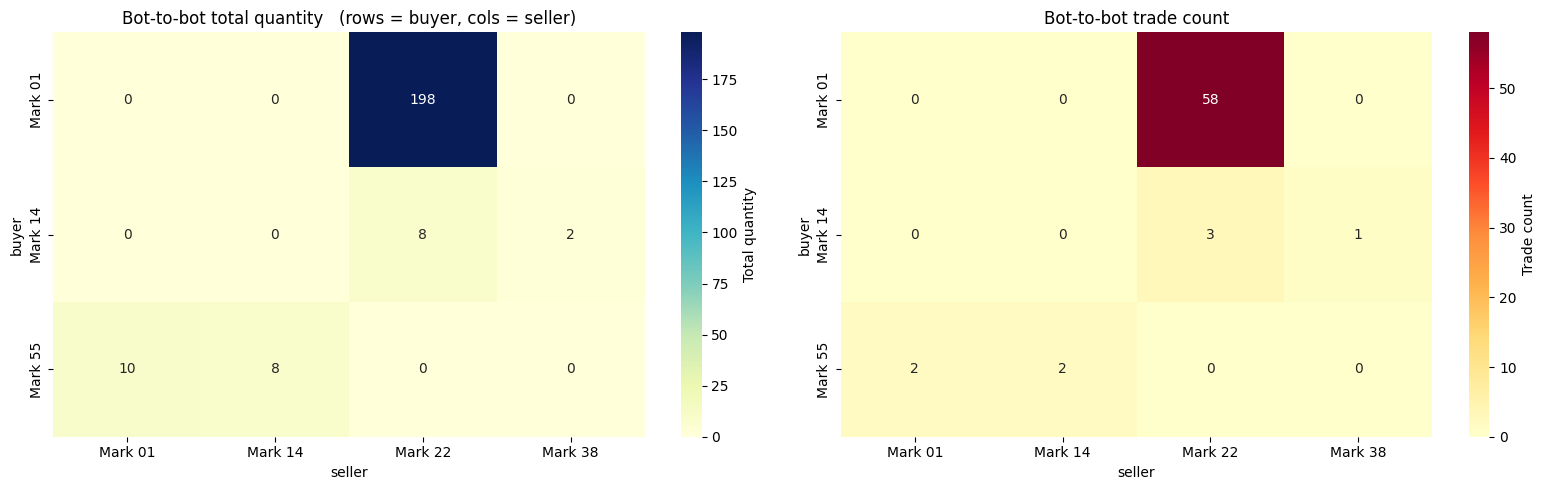


Bot-to-bot per product (count, qty, distinct pairs):
  HYDROGEL_PACK           n=  1  qty=   2  pairs=1
  VELVETFRUIT_EXTRACT     n=  4  qty=  18  pairs=2
  VEV_5200                n=  1  qty=   3  pairs=1
  VEV_5300                n=  6  qty=  17  pairs=1
  VEV_5400                n= 14  qty=  48  pairs=2
  VEV_5500                n= 12  qty=  42  pairs=1
  VEV_6000                n= 14  qty=  48  pairs=1
  VEV_6500                n= 14  qty=  48  pairs=1


In [15]:
def plot_bot_bot_matrix(parsed):
    """Pairing matrix for trades where SUBMISSION is NOT involved."""
    bb = parsed['trades'][parsed['trades']['side'] == 'M'].copy()
    if bb.empty:
        print('No bot-to-bot trades in this log.'); return
    print(f"Total bot-to-bot trades: {len(bb):,}")
    print(f"Distinct (buyer, seller) pairs: {len(bb.groupby(['buyer','seller']))}")

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    pivot_qty = bb.pivot_table(index='buyer', columns='seller', values='quantity',
                                aggfunc='sum', fill_value=0)
    sns.heatmap(pivot_qty, annot=True, fmt='.0f', cmap='YlGnBu', ax=axes[0],
                cbar_kws={'label': 'Total quantity'})
    axes[0].set_title('Bot-to-bot total quantity   (rows = buyer, cols = seller)')

    pivot_n = bb.pivot_table(index='buyer', columns='seller', values='quantity',
                              aggfunc='count', fill_value=0)
    sns.heatmap(pivot_n, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[1],
                cbar_kws={'label': 'Trade count'})
    axes[1].set_title('Bot-to-bot trade count')
    plt.tight_layout(); plt.show()

    print('\nBot-to-bot per product (count, qty, distinct pairs):')
    for sym, g in bb.groupby('symbol'):
        n_pairs = len(g.groupby(['buyer','seller']))
        print(f"  {sym:<22}  n={len(g):>3}  qty={g['quantity'].sum():>4}  pairs={n_pairs}")

plot_bot_bot_matrix(parsed)

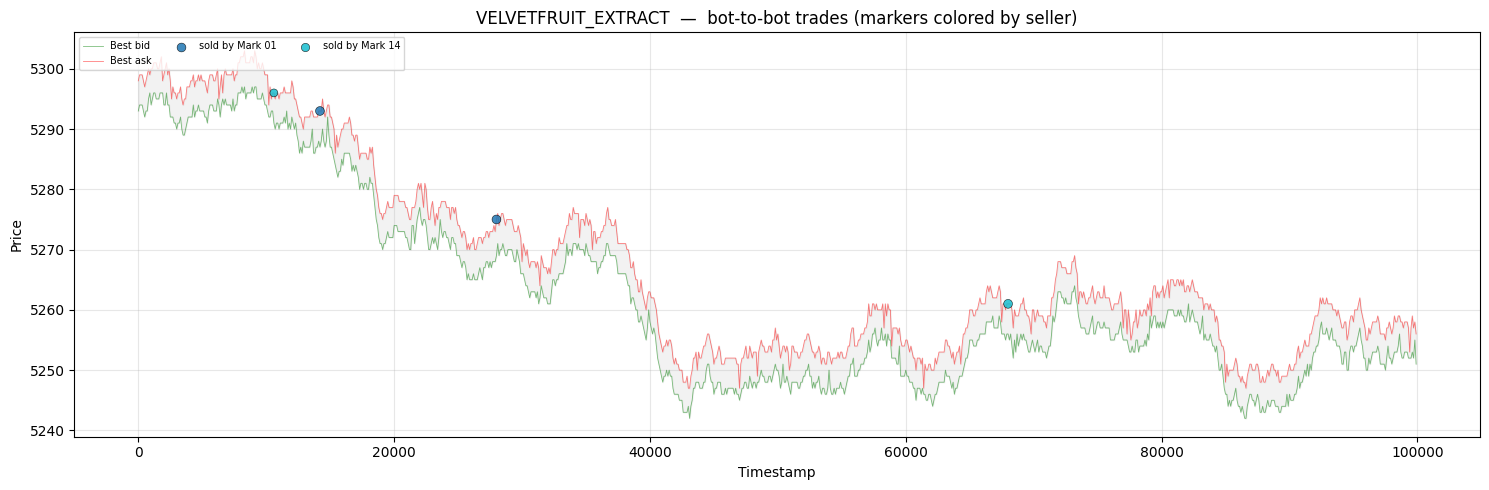


VELVETFRUIT_EXTRACT bot-to-bot fills: 4
By (buyer, seller):
                 n  qty  avg_px
buyer   seller                 
Mark 55 Mark 01  2   10  5284.0
        Mark 14  2    8  5278.5


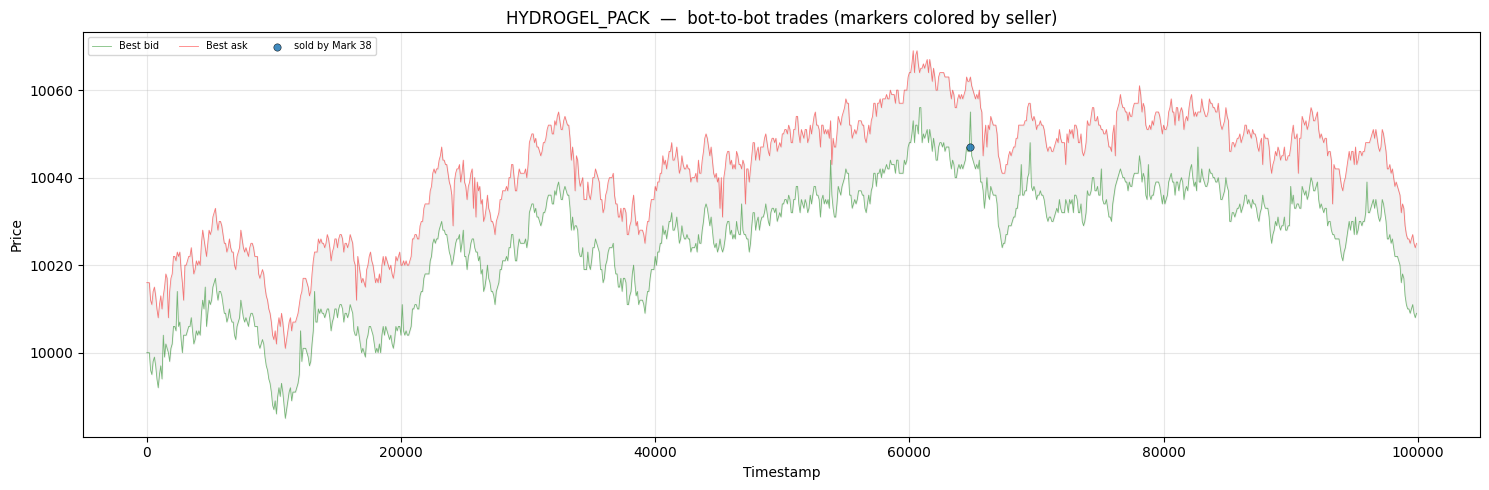


HYDROGEL_PACK bot-to-bot fills: 1
By (buyer, seller):
                 n  qty   avg_px
buyer   seller                  
Mark 14 Mark 38  1    2  10047.0


In [16]:
def plot_bot_bot_markers(parsed, product, ts_window=None):
    """Bid/ask track + bot-to-bot trade markers for one product.
    Mirrors plot_trade_markers but filters to side=='M' and colors by SELLER."""
    book = parsed['book'].get(product)
    if book is None:
        print(f'No book data for {product}'); return
    bb = parsed['trades'][(parsed['trades']['symbol'] == product) &
                          (parsed['trades']['side'] == 'M')]
    if bb.empty:
        print(f'No bot-to-bot trades for {product} in this log.'); return

    if ts_window:
        lo, hi = ts_window
        book = book[(book['timestamp'] >= lo) & (book['timestamp'] <= hi)]
        bb = bb[(bb['timestamp'] >= lo) & (bb['timestamp'] <= hi)]

    fig, ax = plt.subplots(figsize=(15, 5))
    ax.plot(book['timestamp'], book['bid_price_1'], color='green', lw=0.6, alpha=0.5, label='Best bid')
    ax.plot(book['timestamp'], book['ask_price_1'], color='red',   lw=0.6, alpha=0.5, label='Best ask')
    ax.fill_between(book['timestamp'], book['bid_price_1'], book['ask_price_1'], color='gray', alpha=0.1)

    sellers = sorted(bb['seller'].dropna().unique())
    cmap = cm.tab10(np.linspace(0, 1, max(len(sellers), 1)))
    seller_color = {s: cmap[i] for i, s in enumerate(sellers)}
    for s in sellers:
        sel = bb[bb['seller'] == s]
        ax.scatter(sel['timestamp'], sel['price'], s=sel['quantity']*4 + 20,
                   color=seller_color[s], edgecolors='black', linewidths=0.4,
                   alpha=0.85, label=f'sold by {s}', zorder=5)

    ax.set_title(f'{product}  —  bot-to-bot trades (markers colored by seller)')
    ax.set_xlabel('Timestamp'); ax.set_ylabel('Price')
    ax.legend(ncol=3, fontsize=7, loc='upper left')
    ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    print(f'\n{product} bot-to-bot fills: {len(bb)}')
    if len(bb):
        print('By (buyer, seller):')
        print(bb.groupby(['buyer', 'seller']).agg(
            n=('quantity','count'), qty=('quantity','sum'), avg_px=('price','mean')
        ).round(2))

for p in ['VELVETFRUIT_EXTRACT', 'HYDROGEL_PACK']:
    if p in parsed['products']:
        plot_bot_bot_markers(parsed, p)